# Filtros Convolucionales (Kernels) sobre Imágenes a Color (RGB)

En este notebook vamos a:
1. Cargar una imagen **a color (RGB)** desde Google Drive.
2. Definir varios **kernels (filtros)** de procesamiento de imágenes.
3. Aplicar cada kernel sobre los **3 canales de color** (Rojo, Verde, Azul) de forma independiente.
4. Visualizar todos los resultados en una galería.

Los kernels están basados en el resumen de tipos de kernels de convolución de GeeksforGeeks:
https://www.geeksforgeeks.org/deep-learning/types-of-convolution-kernels/


In [ ]:
# =====================================================================
# CLASE: Redes Convolucionales - Tipos de Kernels (Filtros) en RGB
# =====================================================================

# 1. Conectar Google Colab con Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Asegúrate de subir una imagen (por ejemplo, 'mi_imagen.jpg') a tu Drive.
# Modifica la siguiente ruta con la ubicación real de tu archivo en Drive.
ruta_imagen_drive = '/content/drive/MyDrive/CNN/ramirez.jpg'


Mounted at /content/drive


In [ ]:
# 2. Importar las librerías necesarias
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
try:
    # 3. Cargar la imagen desde Drive y mantenerla en RGB (a colores)
    # Nota: a diferencia de la escala de grises (1 solo canal), ahora
    # trabajamos con 3 canales (Rojo, Verde y Azul) para que el resultado
    # final se vea a color.
    imagen_pil = Image.open(ruta_imagen_drive).convert('RGB')
    print("¡Imagen cargada correctamente desde Google Drive (RGB)!")
except FileNotFoundError:
    print(f"Error: No se encontró ningún archivo en la ruta: {ruta_imagen_drive}")
    print("Por favor, verifica el nombre y la extensión del archivo en tu Google Drive.")


¡Imagen cargada correctamente desde Google Drive (RGB)!


In [ ]:
# 4. Preprocesamiento: Convertir la imagen en un Tensor de PyTorch
# transforms.ToTensor() reconoce que la imagen PIL está en modo 'RGB' y
# genera un tensor con forma [Canales=3, Alto, Ancho], con valores en [0, 1].
transformacion = transforms.ToTensor()
imagen_tensor = transformacion(imagen_pil)  # [3, H, W]

# PyTorch requiere que el lote (batch) tenga la forma: [Batch_Size, Canales, Alto, Ancho]
imagen_tensor = imagen_tensor.unsqueeze(0)  # Añadimos la dimensión del lote -> [1, 3, H, W]

print("Forma del tensor de la imagen:", imagen_tensor.shape)


Forma del tensor de la imagen: torch.Size([1, 3, 1147, 860])


## 5. Funciones auxiliares

Para poder aplicar **cualquier** kernel sobre una imagen a color, y luego mostrarla
correctamente, definimos tres funciones reutilizables.

In [ ]:
# =====================================================================
# 5. Funciones auxiliares para aplicar kernels a imágenes en RGB
# =====================================================================

def convolucionar_rgb(imagen_tensor, kernel_2d, padding=None):
    """
    Aplica un mismo kernel 2D a una imagen a color (RGB), de forma
    INDEPENDIENTE en cada canal (Rojo, Verde y Azul).

    ¿Por qué 'groups=3'? Por defecto, F.conv2d mezclaría los 3 canales de
    entrada para producir cada canal de salida (eso es lo que se necesita,
    por ejemplo, dentro de una red neuronal convolucional). Pero aquí
    queremos que el filtro se aplique IGUAL y por separado en R, G y B,
    sin mezclar información entre canales. Usando 'groups=3' logramos
    justamente eso: cada canal de salida usa solo su propio canal de
    entrada con su propia copia del kernel.

    Parámetros:
        imagen_tensor -> tensor de forma [1, 3, H, W]
        kernel_2d     -> arreglo de NumPy de forma [kh, kw]
        padding       -> si es None, se calcula automáticamente para
                          conservar el tamaño original de la imagen
                          (padding "same", válido para kernels cuadrados
                          de tamaño impar)
    Retorna:
        Tensor de forma [1, 3, H, W] con el filtro ya aplicado.
    """
    kh, kw = kernel_2d.shape
    if padding is None:
        padding = kh // 2  # padding "same"

    # Convertimos el kernel de NumPy a Tensor de PyTorch
    kernel_tensor = torch.from_numpy(kernel_2d.astype(np.float32))

    # Forma requerida por conv2d agrupada:
    # [canales_salida, canales_entrada/grupos, alto, ancho] -> [3, 1, kh, kw]
    # Repetimos el mismo kernel 3 veces, una por cada canal de color.
    kernel_tensor = kernel_tensor.view(1, 1, kh, kw).repeat(3, 1, 1, 1)

    salida = F.conv2d(imagen_tensor, kernel_tensor, padding=padding, groups=3)
    return salida


def tensor_a_imagen(tensor, normalizar=True):
    """
    Convierte un tensor de imagen [1, 3, H, W] (o [3, H, W]) en un arreglo
    de NumPy [H, W, 3] listo para mostrarse con matplotlib (imshow).

    Importante: cuando matplotlib grafica una imagen en escala de grises
    (1 canal) auto-ajusta el contraste según el mínimo y máximo de los
    datos. Pero para imágenes a color (3 canales) NO hace ese ajuste
    automático: espera valores ya en el rango [0, 1]. Como kernels como
    los de bordes, enfoque o Laplaciano pueden generar valores negativos
    o mayores a 1, necesitamos reescalarlos nosotros mismos antes de
    graficar, o de lo contrario se verían recortados (saturados en
    negro o blanco).

    Parámetros:
        normalizar -> si True, reescala la imagen a [0, 1] usando su
                      propio mínimo y máximo (ideal para bordes, enfoque,
                      Laplaciano, Sobel, Prewitt, Scharr, Gabor...).
                      Si False, simplemente recorta (clip) los valores
                      al rango [0, 1] (ideal para la imagen original o
                      para desenfoques, que ya están en un rango razonable).
    """
    if tensor.dim() == 4:
        tensor = tensor.squeeze(0)  # quitamos la dimensión de batch -> [3, H, W]

    img = tensor.detach().numpy()
    img = np.transpose(img, (1, 2, 0))  # [3, H, W] -> [H, W, 3] (lo que espera matplotlib)

    if normalizar:
        minimo, maximo = img.min(), img.max()
        if maximo - minimo > 1e-8:
            img = (img - minimo) / (maximo - minimo)
        else:
            img = np.clip(img, 0, 1)
    else:
        img = np.clip(img, 0, 1)

    return img


def generar_kernel_gabor(tam=15, sigma=4.0, theta=0.0, lambd=10.0, psi=0.0, gamma=0.5):
    """
    Genera un kernel de Gabor 2D.

    El filtro de Gabor combina una "envolvente" Gaussiana con una onda
    sinusoidal. Gracias a esto puede capturar información de orientación
    y frecuencia espacial al mismo tiempo, lo cual es muy útil para
    analizar texturas y detectar bordes en una dirección específica
    (a diferencia de Sobel/Prewitt, que solo dan horizontal o vertical).

    Parámetros:
        tam    -> tamaño del kernel (tam x tam); usar un número impar
        sigma  -> desviación estándar de la envolvente Gaussiana
                  (qué tan "ancho" es el filtro)
        theta  -> orientación del filtro, en radianes (0 = horizontal)
        lambd  -> longitud de onda de la componente sinusoidal
        psi    -> desfase (fase) de la onda
        gamma  -> relación de aspecto espacial de la envolvente Gaussiana
    """
    mitad = tam // 2
    y, x = np.meshgrid(np.arange(-mitad, mitad + 1), np.arange(-mitad, mitad + 1))

    # Rotamos las coordenadas según la orientación deseada (theta)
    x_theta = x * np.cos(theta) + y * np.sin(theta)
    y_theta = -x * np.sin(theta) + y * np.cos(theta)

    kernel = np.exp(-(x_theta ** 2 + (gamma ** 2) * y_theta ** 2) / (2 * sigma ** 2)) \
             * np.cos(2 * np.pi * x_theta / lambd + psi)

    return kernel.astype(np.float32)


## 6. Definición de los kernels

Todos los kernels siguientes están explicados en:
https://www.geeksforgeeks.org/deep-learning/types-of-convolution-kernels/

Los agrupamos en tres categorías, igual que en el artículo: **básicos**, **avanzados** y **especializados**.

In [ ]:
# =====================================================================
# 6. Definición de los kernels (filtros)
# =====================================================================

kernels = {}

# ---------- Kernels básicos ----------

# Identidad: deja la imagen igual. El centro vale 1 y el resto 0, así que
# cada píxel "se convoluciona consigo mismo". Sirve para comprobar que la
# convolución está funcionando correctamente.
kernels["Identidad"] = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
], dtype=np.float32)

# Identidad x50: la misma idea, pero multiplicando el centro por 50.
# Permite observar qué pasa cuando un kernel "amplifica" demasiado la
# intensidad de cada píxel (la imagen se satura).
kernels["Identidad x50"] = np.array([
    [0, 0, 0],
    [0, 50, 0],
    [0, 0, 0]
], dtype=np.float32)

# Detección de bordes horizontales: resalta cambios de intensidad en
# dirección vertical, es decir, encuentra líneas horizontales.
kernels["Bordes Horizontales"] = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
], dtype=np.float32)

# Detección de bordes verticales: resalta cambios de intensidad en
# dirección horizontal, es decir, encuentra líneas verticales.
kernels["Bordes Verticales"] = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

# Enfoque (sharpen): amplifica la diferencia entre un píxel y sus vecinos,
# haciendo que los bordes se vean más marcados y la imagen más "nítida".
kernels["Enfoque (Sharpen)"] = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)

# Desenfoque de caja (box blur): promedia cada píxel con sus 8 vecinos,
# suavizando la imagen. Todos los pesos son iguales (1/9 cada uno).
kernels["Desenfoque de Caja"] = np.ones((3, 3), dtype=np.float32) / 9

# ---------- Kernels avanzados ----------

# Desenfoque Gaussiano: parecido al desenfoque de caja, pero le da más
# peso al píxel central y menos a los más alejados, logrando un
# suavizado más "natural" (menos artificial que el de caja).
kernels["Desenfoque Gaussiano"] = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 16

# Sobel: aproxima la primera derivada de la intensidad (el "gradiente"),
# es decir, mide qué tan rápido cambia el color de un punto a otro.
# Existen versiones horizontal y vertical.
kernels["Sobel Horizontal"] = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

kernels["Sobel Vertical"] = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=np.float32)

# Prewitt: muy similar a Sobel, también calcula gradientes horizontales y
# verticales, pero con pesos uniformes (sin el "2" central de Sobel).
kernels["Prewitt Horizontal"] = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

kernels["Prewitt Vertical"] = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
], dtype=np.float32)

# Laplaciano: operador de SEGUNDA derivada. Es más sensible al ruido,
# pero detecta bordes en todas las direcciones a la vez (no distingue
# horizontal de vertical, como sí lo hacen Sobel o Prewitt).
kernels["Laplaciano"] = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
], dtype=np.float32)

# ---------- Kernels especializados ----------

# Scharr: una variante de Sobel/Prewitt pensada para tener mejor simetría
# rotacional, lo que da una detección de bordes más precisa.
kernels["Scharr Horizontal"] = np.array([
    [3, 0, -3],
    [10, 0, -10],
    [3, 0, -3]
], dtype=np.float32)

kernels["Scharr Vertical"] = np.array([
    [3, 10, 3],
    [0, 0, 0],
    [-3, -10, -3]
], dtype=np.float32)

# Gabor: combina una Gaussiana con una onda sinusoidal para detectar
# bordes y texturas en una orientación específica. A diferencia de los
# anteriores, no es una matriz fija de 3x3: se genera con una función,
# según el ángulo (theta) que queramos analizar.
kernels["Gabor (0 grados)"] = generar_kernel_gabor(theta=0)
kernels["Gabor (45 grados)"] = generar_kernel_gabor(theta=np.pi / 4)
kernels["Gabor (90 grados)"] = generar_kernel_gabor(theta=np.pi / 2)

print(f"Se definieron {len(kernels)} kernels:")
for nombre in kernels:
    print(" -", nombre)


Se definieron 17 kernels:
 - Identidad
 - Identidad x50
 - Bordes Horizontales
 - Bordes Verticales
 - Enfoque (Sharpen)
 - Desenfoque de Caja
 - Desenfoque Gaussiano
 - Sobel Horizontal
 - Sobel Vertical
 - Prewitt Horizontal
 - Prewitt Vertical
 - Laplaciano
 - Scharr Horizontal
 - Scharr Vertical
 - Gabor (0 grados)
 - Gabor (45 grados)
 - Gabor (90 grados)


In [ ]:
# =====================================================================
# 7. Aplicar todos los kernels a la imagen en RGB
# =====================================================================

resultados = {}

for nombre, kernel in kernels.items():
    resultados[nombre] = convolucionar_rgb(imagen_tensor, kernel)

print("¡Listo! Se aplicaron todos los kernels sobre la imagen a color (RGB).")


¡Listo! Se aplicaron todos los kernels sobre la imagen a color (RGB).


## 8. Galería de resultados

Mostramos la imagen original junto al resultado de cada kernel. Como se explicó antes,
normalizamos cada resultado a `[0, 1]` para poder visualizarlo correctamente a color.

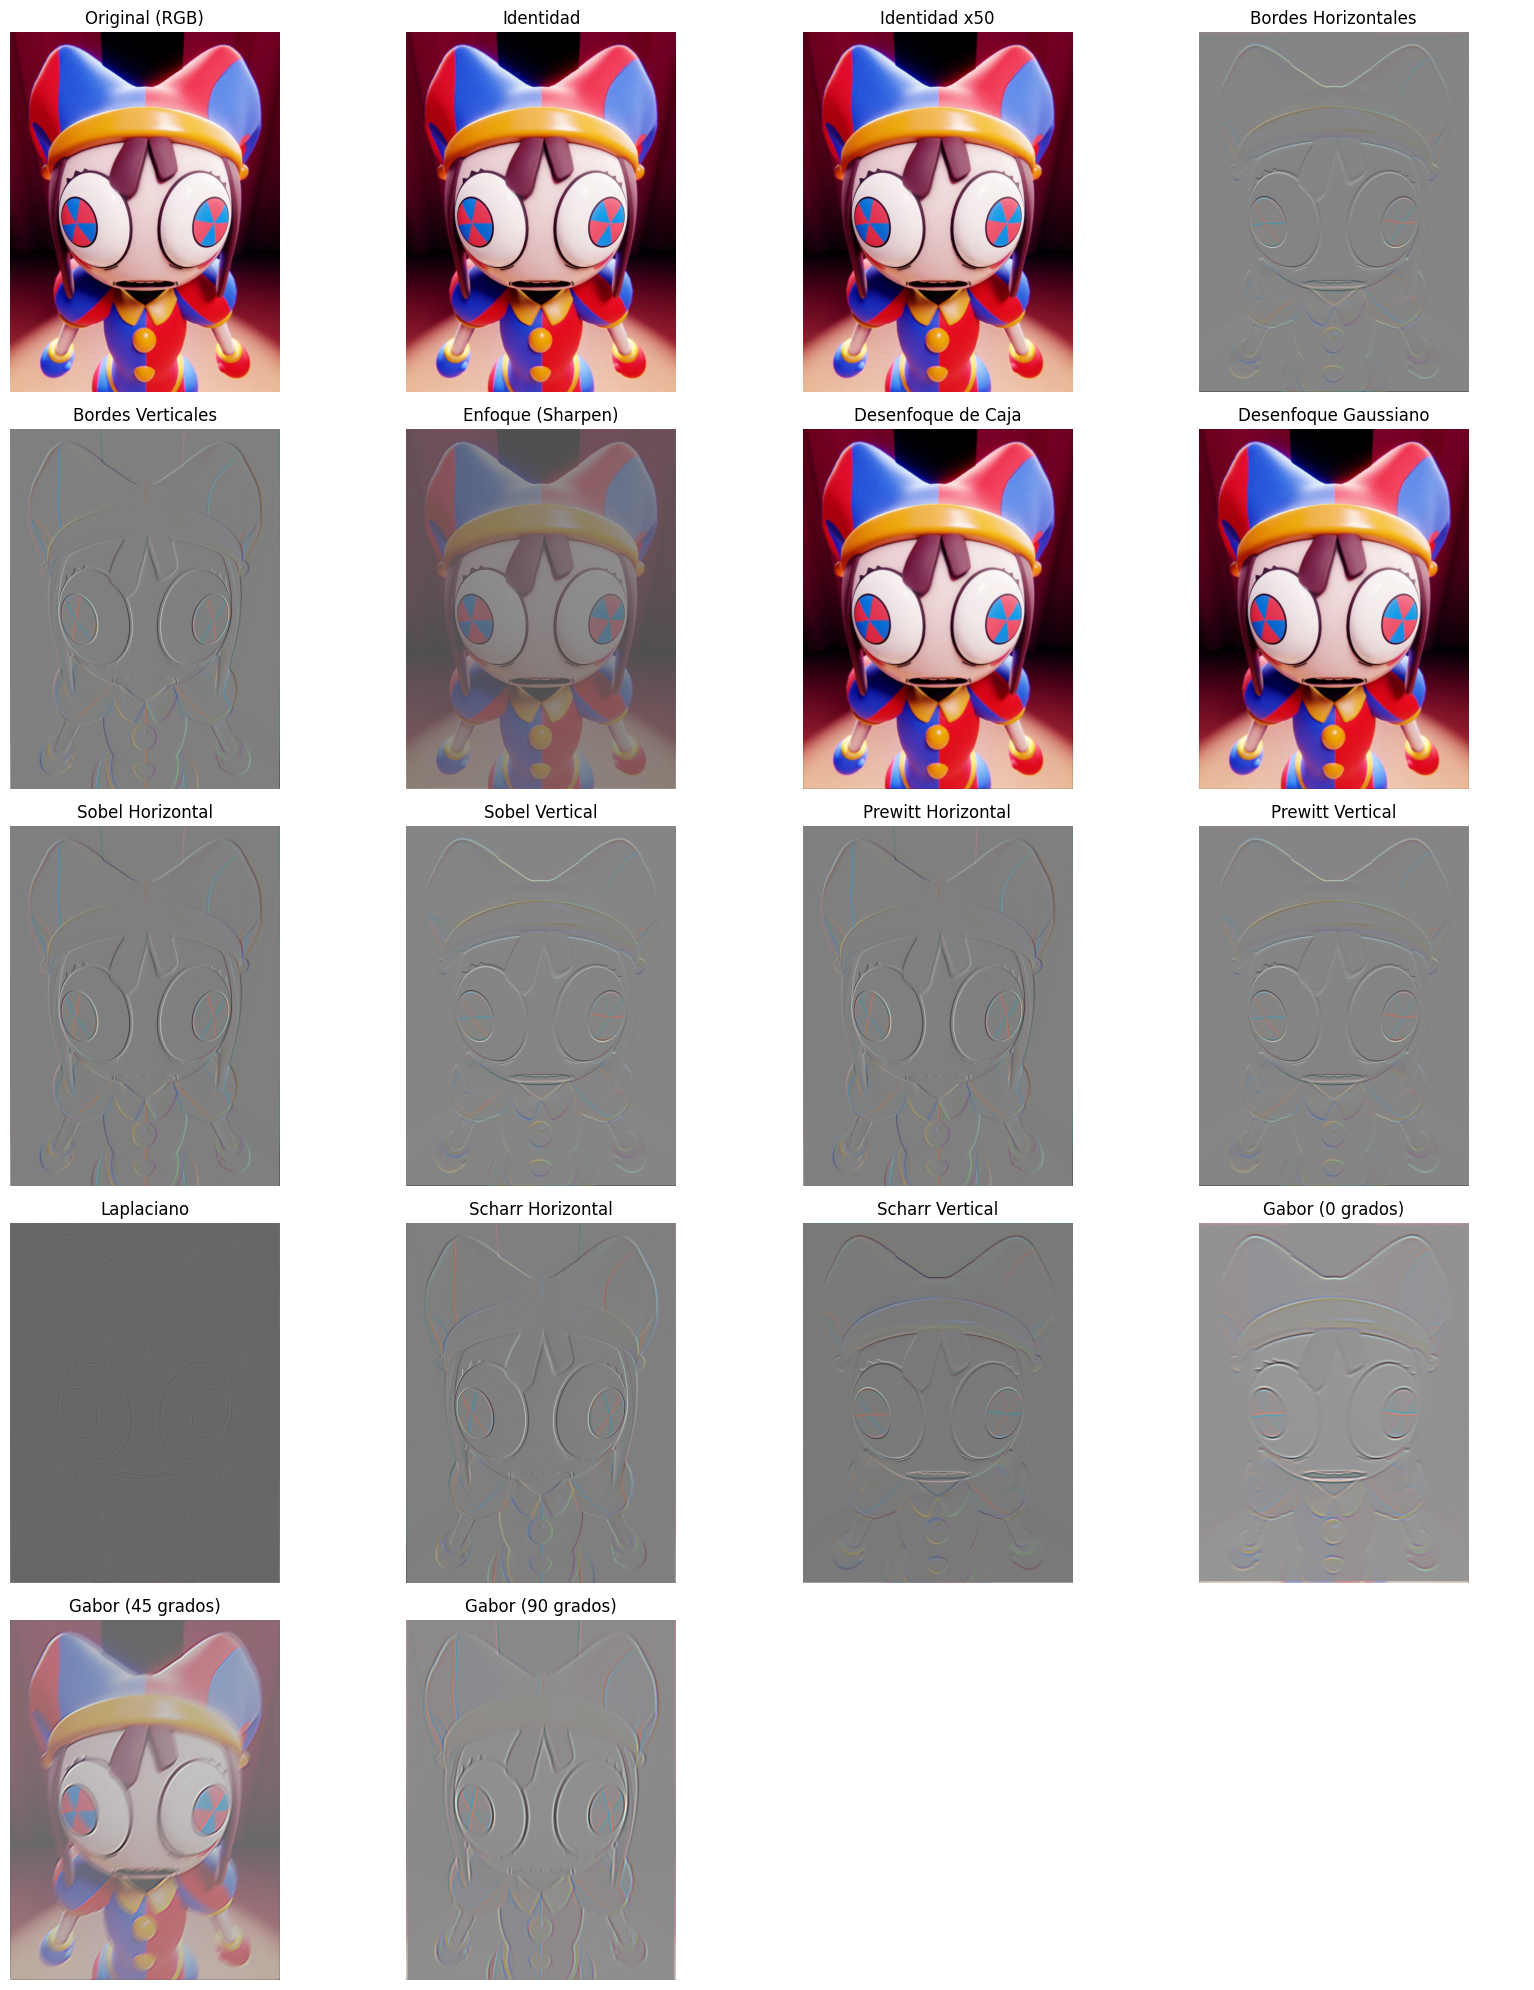

In [ ]:
# =====================================================================
# 8. Visualización: imagen original + resultado de cada kernel
# =====================================================================

def mostrar_galeria(imagen_original_tensor, resultados, columnas=4, normalizar=True):
    """
    Muestra, en una sola figura, la imagen original y el resultado de
    aplicar cada kernel del diccionario 'resultados'.

    Parámetros:
        imagen_original_tensor -> tensor [1, 3, H, W] de la imagen original
        resultados              -> diccionario {nombre_kernel: tensor_resultado}
        columnas                -> cuántas imágenes mostrar por fila
        normalizar               -> si True, reescala cada resultado a [0, 1]
                                     (ver explicación en 'tensor_a_imagen')
    """
    total_imagenes = len(resultados) + 1  # +1 por la imagen original
    filas = int(np.ceil(total_imagenes / columnas))

    fig, axes = plt.subplots(filas, columnas, figsize=(4 * columnas, 4 * filas))
    axes = axes.flatten()

    # Primero mostramos la imagen original (sin normalizar: ya está en [0, 1])
    img_original = tensor_a_imagen(imagen_original_tensor, normalizar=False)
    axes[0].imshow(img_original)
    axes[0].set_title("Original (RGB)", fontsize=12)
    axes[0].axis('off')

    # Luego, una imagen por cada kernel aplicado
    for i, (nombre, tensor_resultado) in enumerate(resultados.items(), start=1):
        img = tensor_a_imagen(tensor_resultado, normalizar=normalizar)
        axes[i].imshow(img)
        axes[i].set_title(nombre, fontsize=12)
        axes[i].axis('off')

    # Apagamos los ejes que quedaron sin usar (si la grilla no es exacta)
    for j in range(total_imagenes, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


mostrar_galeria(imagen_tensor, resultados, columnas=4)


## 9. Ejemplo: revisar un kernel puntual

Como guardamos todo en el diccionario `resultados`, podemos comparar la imagen original
contra **cualquier** filtro específico sin tener que volver a calcular la convolución.

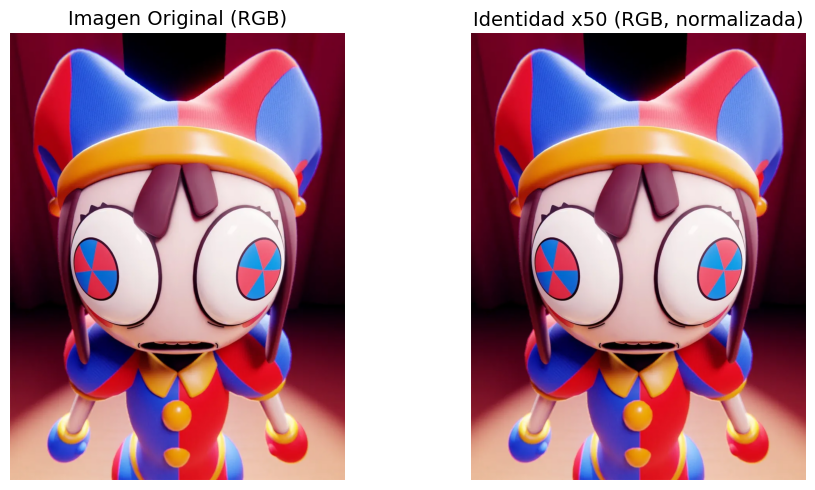

In [ ]:
# =====================================================================
# 9. Ejemplo: comparar la imagen original contra un kernel específico
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(tensor_a_imagen(imagen_tensor, normalizar=False))
axes[0].set_title("Imagen Original (RGB)", fontsize=14)
axes[0].axis('off')

# Puedes cambiar "Identidad x50" por cualquier otro nombre del diccionario
# 'kernels', por ejemplo: "Sobel Vertical", "Desenfoque Gaussiano", etc.
axes[1].imshow(tensor_a_imagen(resultados["Identidad x50"], normalizar=True))
axes[1].set_title("Identidad x50 (RGB, normalizada)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 10. Método alternativo: filtrar en escala de grises y "convertir" a color al final

Una forma distinta de hacer este ejercicio es:

1. Cargar la imagen en **escala de grises** (1 solo canal) y aplicar ahí los kernels.
   Como solo hay un canal de números, el efecto de cada filtro se aprecia más claro
   y sin la "interferencia" visual de tener 3 canales a la vez.
2. **Al final**, convertir el resultado (que sigue siendo blanco y negro) a un tensor
   de 3 canales usando `torch.stack` (para apilar 3 copias del mismo canal gris) y
   `unsqueeze`/`squeeze` (para ajustar las dimensiones de batch), solo para poder
   mostrarlo con `imshow` en formato RGB.

**Importante:** esto NO agrega color real a la imagen. El resultado sigue siendo gris,
solo que ahora está "empaquetado" como si fueran 3 canales iguales (R = G = B).
Por eso el método original (aplicar el kernel directamente sobre cada
canal de color real, con `groups=3`) es más "limpio": ahí sí se está filtrando el
color de verdad, no solo simulando el formato. Aun así, este método alternativo es
útil cuando lo que más importa es apreciar bien la forma del kernel.

In [ ]:
# =====================================================================
# 10.1 Cargar la imagen en escala de grises (alternativa)
# =====================================================================

# Cargamos una segunda versión de la imagen, esta vez en escala de grises
# ('L' = luminancia, 1 solo canal). La imagen a color (imagen_pil) y el
# tensor RGB (imagen_tensor) de las secciones anteriores quedan intactos.
imagen_pil_gris = Image.open(ruta_imagen_drive).convert('L')

imagen_tensor_gris = transformacion(imagen_pil_gris)      # [1, H, W]
imagen_tensor_gris = imagen_tensor_gris.unsqueeze(0)      # [1, 1, H, W] (batch, 1 canal)

print("Forma del tensor en escala de grises:", imagen_tensor_gris.shape)


Forma del tensor en escala de grises: torch.Size([1, 1, 1147, 860])


In [ ]:
# =====================================================================
# 10.2 Funciones para el método alternativo (gris -> kernel -> "color")
# =====================================================================

def convolucionar_gris(imagen_tensor_gris, kernel_2d, padding=None):
    """
    Aplica un kernel 2D a una imagen de 1 solo canal (escala de grises).

    A diferencia de 'convolucionar_rgb', aquí NO necesitamos 'groups',
    porque solo hay 1 canal de entrada y 1 de salida: no hay nada que
    mantener separado.

    Parámetros:
        imagen_tensor_gris -> tensor de forma [1, 1, H, W]
        kernel_2d           -> arreglo de NumPy de forma [kh, kw]
        padding              -> si es None, se calcula para conservar el
                                 tamaño original ("same")
    Retorna:
        Tensor de forma [1, 1, H, W] con el filtro aplicado.
    """
    kh, kw = kernel_2d.shape
    if padding is None:
        padding = kh // 2

    kernel_tensor = torch.from_numpy(kernel_2d.astype(np.float32))
    kernel_tensor = kernel_tensor.view(1, 1, kh, kw)  # [out=1, in=1, kh, kw]

    salida = F.conv2d(imagen_tensor_gris, kernel_tensor, padding=padding)
    return salida


def gris_a_rgb(tensor_gris):
    """
    Convierte un resultado en escala de grises (1 canal) en un tensor de
    3 canales, repitiendo el mismo valor de gris en R, G y B. Esto NO crea
    color real (el resultado sigue siendo blanco y negro), pero permite
    mostrarlo en un formato "a color" de 3 canales, tal como mencionaron:
    usando 'torch.stack' para apilar 3 copias del canal gris, y
    'unsqueeze' para volver a darle la forma de batch que espera PyTorch.
    """
    # Quitamos las dimensiones de batch/canal sobrantes hasta dejar [H, W]
    while tensor_gris.dim() > 2:
        tensor_gris = tensor_gris.squeeze(0)

    # torch.stack apila 3 copias del mismo canal gris, creando una nueva
    # dimensión de "canales" -> [3, H, W]
    tensor_rgb = torch.stack([tensor_gris, tensor_gris, tensor_gris], dim=0)

    # Volvemos a agregar la dimensión de batch -> [1, 3, H, W]
    tensor_rgb = tensor_rgb.unsqueeze(0)

    return tensor_rgb


In [ ]:
# =====================================================================
# 10.3 Aplicar todos los kernels sobre la imagen en escala de grises,
#      y luego "convertir" cada resultado a formato de 3 canales
# =====================================================================

resultados_gris_a_color = {}

for nombre, kernel in kernels.items():
    salida_gris = convolucionar_gris(imagen_tensor_gris, kernel)   # [1, 1, H, W]
    resultados_gris_a_color[nombre] = gris_a_rgb(salida_gris)      # [1, 3, H, W]

# También convertimos la imagen original en gris al mismo formato, para
# poder mostrarla junto a los resultados con la misma función de galería.
imagen_gris_como_rgb = gris_a_rgb(imagen_tensor_gris)

print("¡Listo! Mismo conjunto de kernels, aplicados sobre escala de grises")
print("y luego empaquetados como tensores de 3 canales para visualizar.")


¡Listo! Mismo conjunto de kernels, aplicados sobre escala de grises
y luego empaquetados como tensores de 3 canales para visualizar.


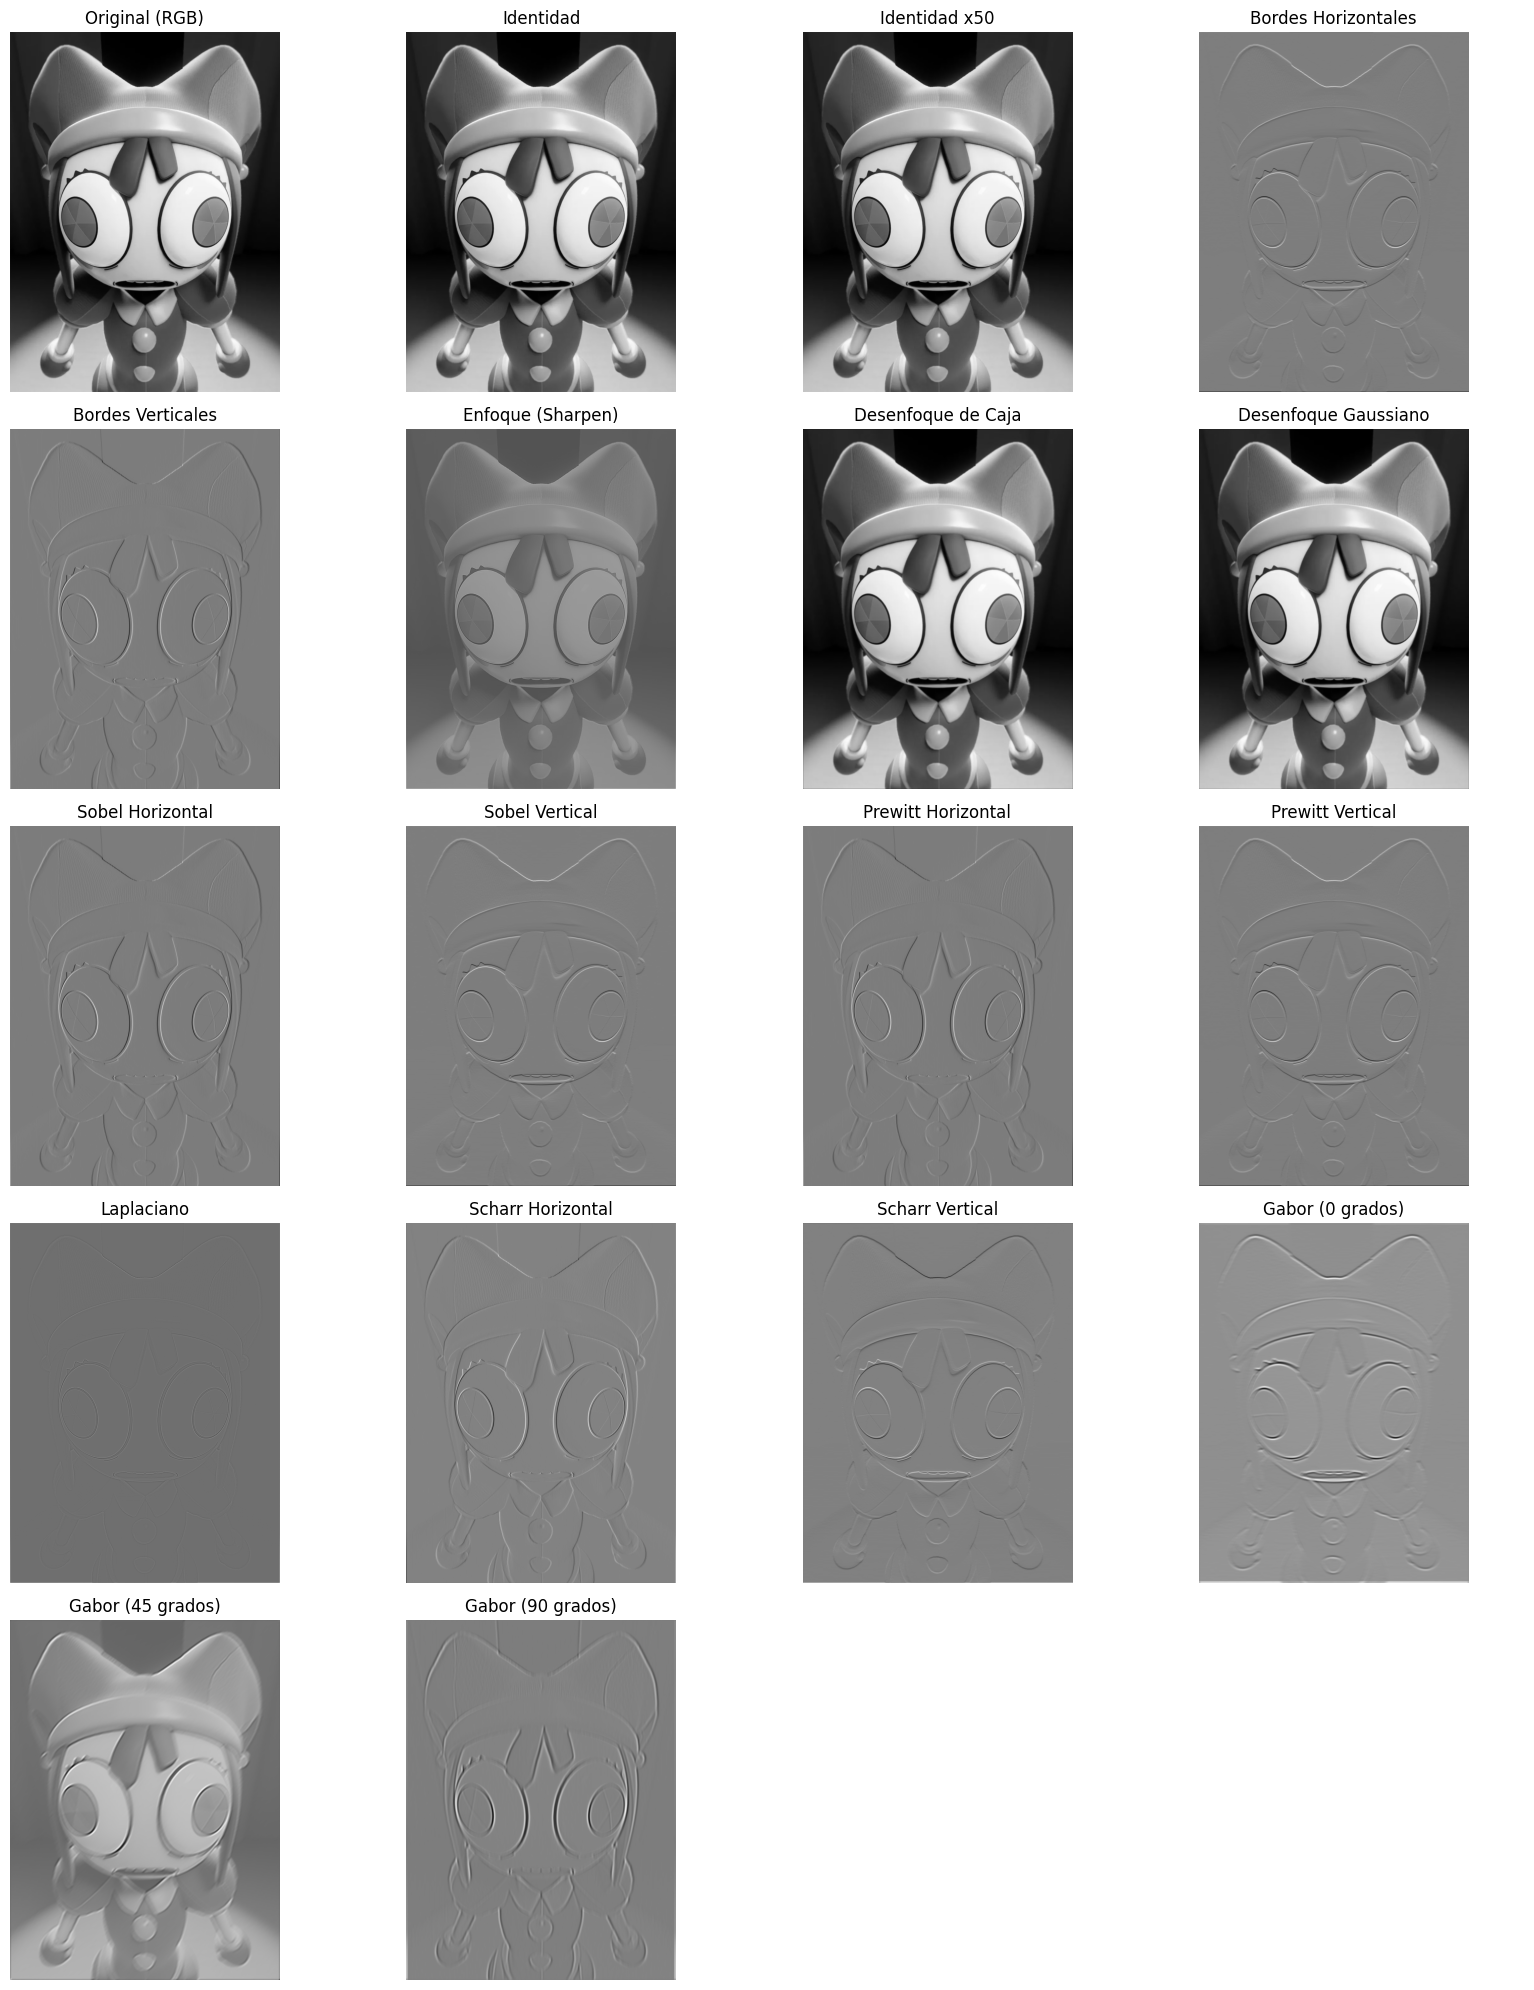

In [ ]:
# =====================================================================
# 10.4 Galería del método alternativo (gris -> kernel -> "color")
# =====================================================================

mostrar_galeria(imagen_gris_como_rgb, resultados_gris_a_color, columnas=4)


### Comparando los dos métodos

- **Nuestro método (Secciones 5-8):** el kernel se aplica directamente sobre los 3
  canales de color reales (`groups=3`). El resultado conserva información de color
  de verdad: por ejemplo, en un desenfoque, los colores se siguen viendo mezclados
  de forma natural; en un kernel de bordes, se nota si el cambio de intensidad fue
  más fuerte en un canal que en otro.
- **Método alternativo (Sección 10):** el kernel se aplica sobre 1 solo canal
  (gris), donde el efecto del filtro se lee más fácilmente porque no hay 3 canales
  compitiendo visualmente. Al final, se "disfraza" de imagen de 3 canales con
  `torch.stack` + `unsqueeze`, pero sigue siendo blanco y negro: no hay color real
  de vuelta.

Ambos son válidos; simplemente responden preguntas distintas:
¿quieres ver el filtro lo más claro posible (gris), o ver cómo afecta realmente
los colores de la imagen (RGB real)?